In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read Data
df = pd.read_csv("smartcart_customers.csv")
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0


In [3]:
df.shape

(2240, 22)

### 1. Data Preprocessing

In [4]:
# Handle Missing Values
df["Income"] = df["Income"].fillna(df["Income"].median())
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 2. Feature Engineering

In [5]:
# Handle Dates
# a. Age
df["Age"] = 2026-df["Year_Birth"]

# b. Date of Joining
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312


In [6]:
# Grouping Columns

# a. Total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# b. Total Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]


In [7]:
# c. Education
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate",
})
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [8]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. Drop Columns

In [9]:
general_cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = general_cols + spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

df_cleaned.shape

(2240, 15)

In [10]:
df_cleaned.head(3)

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner


### 4. Handling Outliers

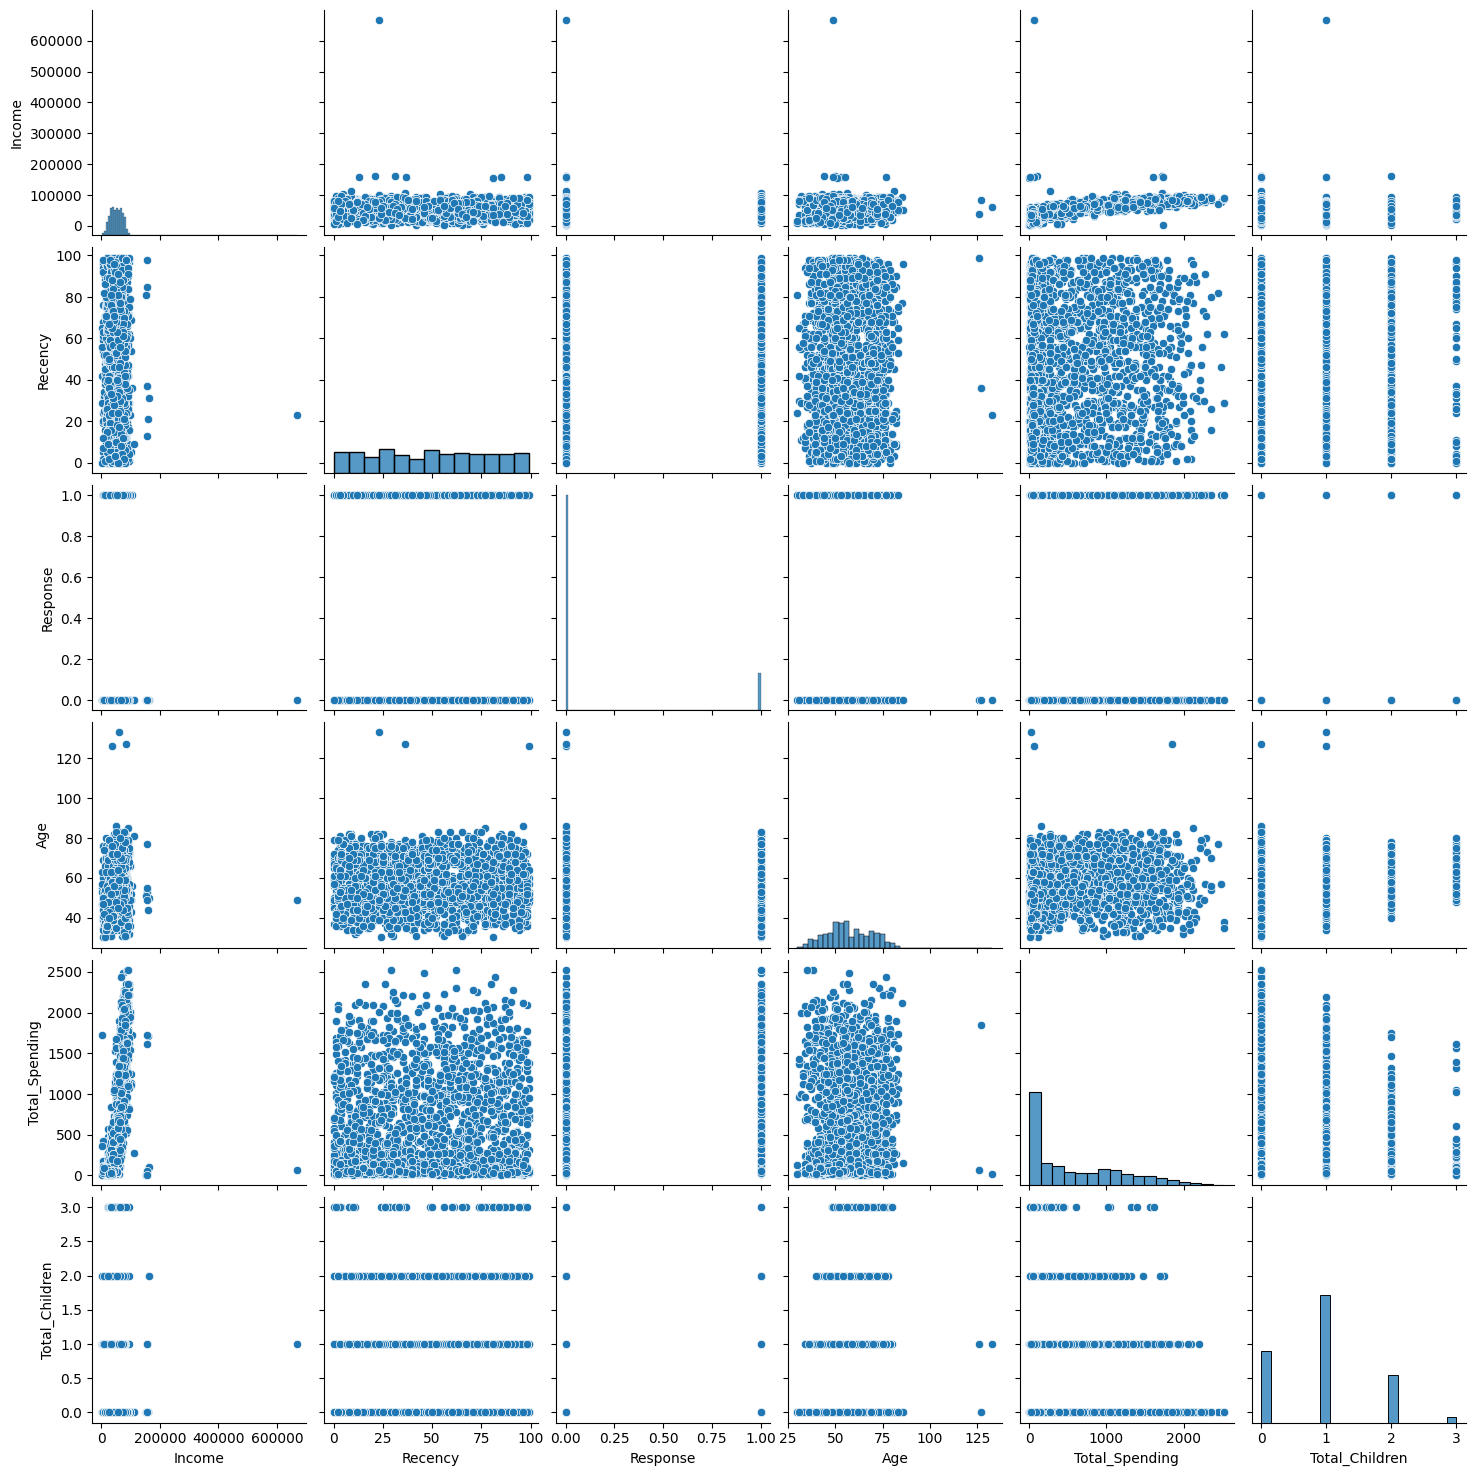

In [11]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Pair Plot
sns.pairplot(df_cleaned[cols])

In [12]:
# Remove Outliers
print("Data size with outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600000)]

print("Data size without outliers: ", len(df_cleaned))

Data size with outliers:  2240
Data size without outliers:  2236


### 5. Heatmap of Features

<Axes: >

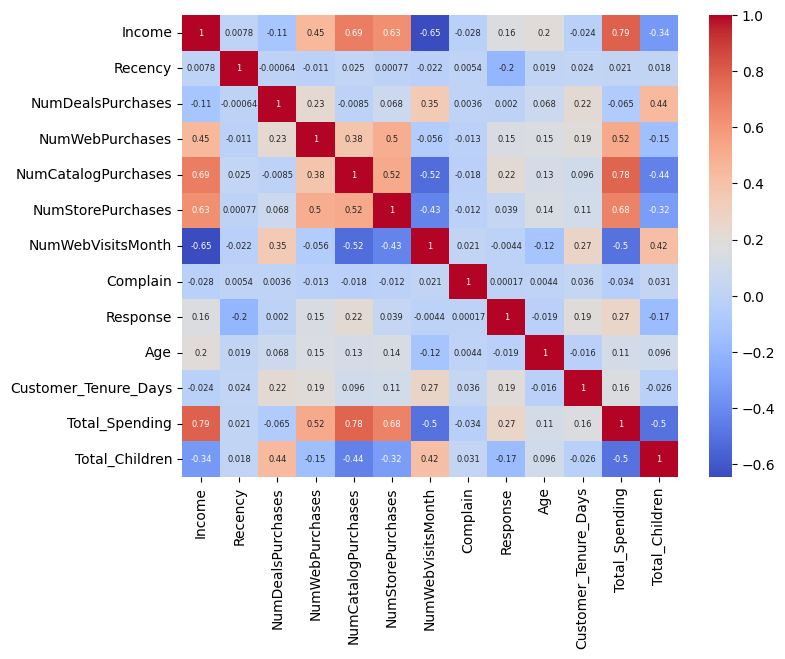

In [13]:
# Correlation Matrix
corr = df_cleaned.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

### 6. Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)
enc_df.head(3)

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0


In [15]:
encoded_df = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)
encoded_df.head(3)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0


### 7. Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

X = encoded_df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Visualize

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d Projection')

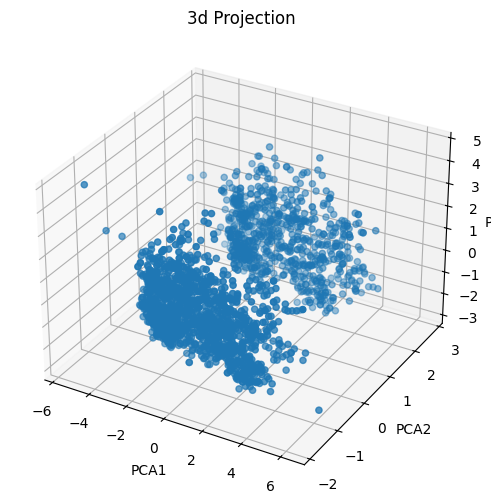

In [18]:
# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

### K-Means Clustering

Best k value:  4


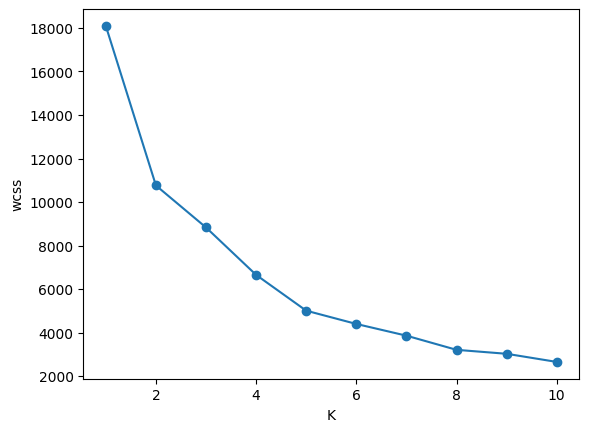

In [19]:
# 1. Elbow Method
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

# Plot
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

print("Best k value: ", optimal_k)

Text(0, 0.5, 'Silhouette score')

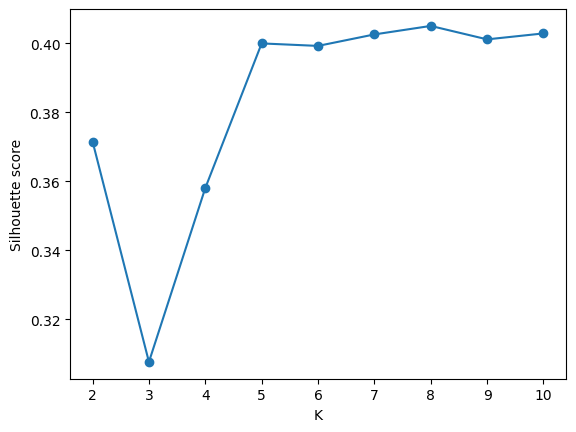

In [20]:
# 2. Silhouette Score
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot (choose higher silhouette score)
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

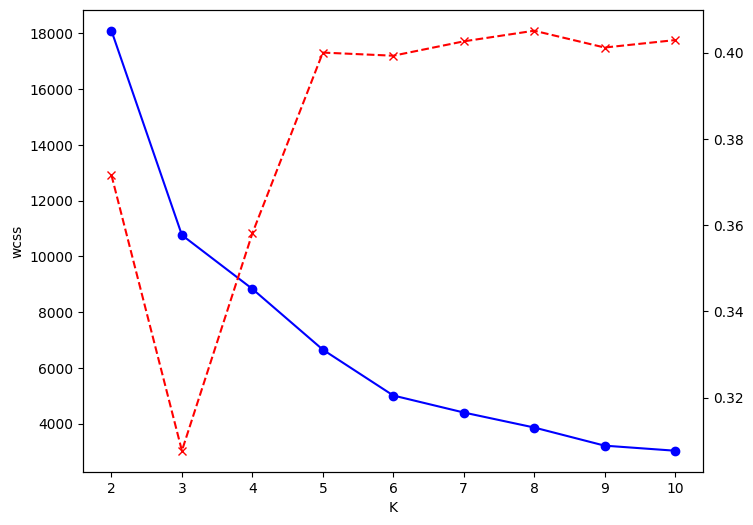

In [21]:
# Combined Plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker='o', color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker='x', color="red", linestyle="--")

Text(0.5, 0.92, '3d Projection')

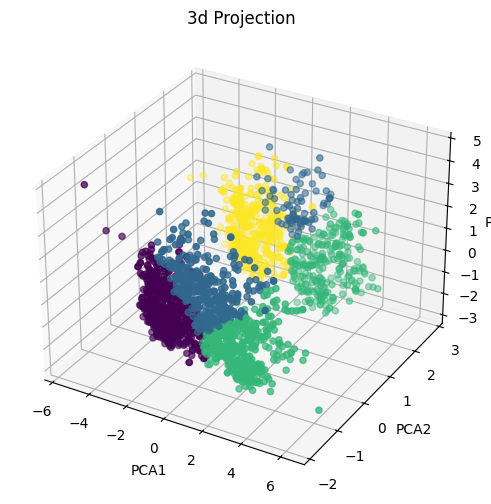

In [22]:
# K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

### Agglomerative Clustering

Text(0.5, 0.92, '3d Projection')

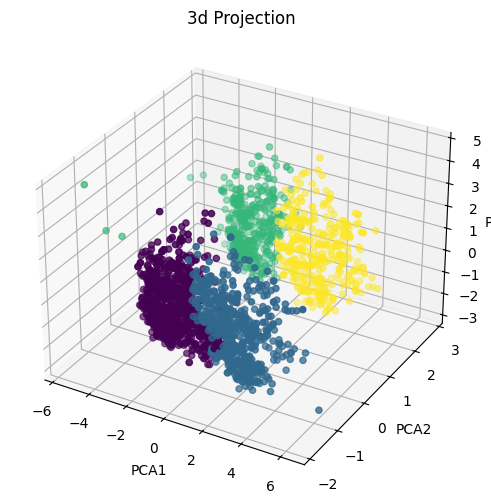

In [23]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels = agg_clf.fit_predict(X_pca)

# Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

### Characterization of Clusters

In [24]:
X["cluster"] = labels
X.head(3)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster', ylabel='count'>

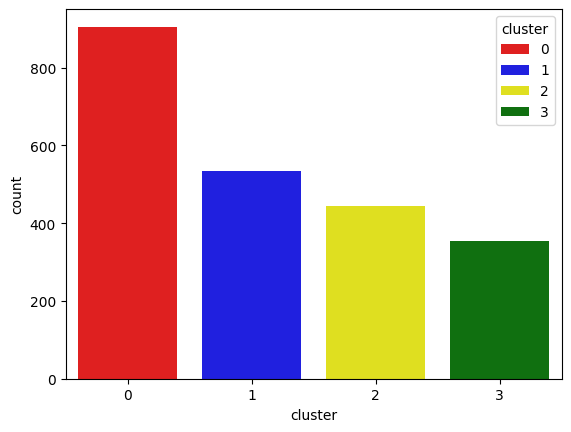

In [25]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

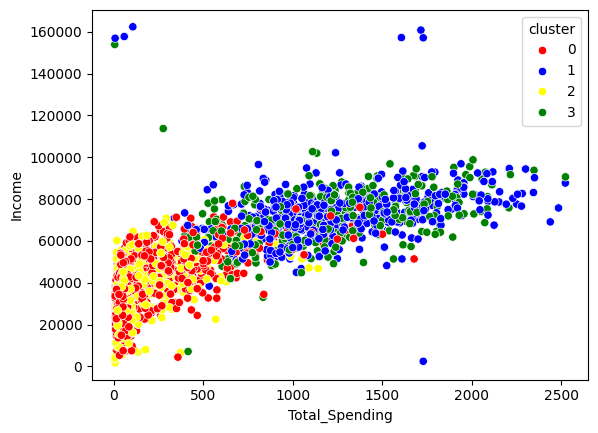

In [26]:
# Income & Spending patterns
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

#### Note:
- Cluster 0: Low/Moderate Income & Low/Moderate Spending
- Cluster 1: Moderate/High Income & Moderate/High Spending
- Cluster 2: Low/Moderate Income & Low Spending
- Cluster 3: Moderate/High Income & Moderate/High Spending

### Cluster Summary

In [27]:
cluster_summary = X.groupby("cluster").mean()
print("Cluster summary:", cluster_summary)

Cluster summary:                Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \

- **C0:** More children, Poor Response, Partner, Web visit,   Low Catalog purchase
- **C1:** Less children, Avg Response,  Partner, Store visit, High Catalog purchase
- **C2:** More children, Avg Response,  Alone,   Web visit,   Low Catalog purchase
- **C3:** Less children, Good Response, Alone,   Store visit, High Catalog purchase